# Hard-negative pressure: DNLL vs logistic loss on synthetic data

This reproduces the comparison in `audit_hard_negative_pressure.py` with a small neural encoder. Three two-dimensional Gaussian classes use the means, shared covariance, and uniform priors from `lda/plots/Sample.ipynb`. Train and test are independent samples from the same distribution. Both losses train the same encoder + `LDAHead` architecture from identical initial parameters and with the same minibatch order.

At each epoch, **hard5** is the top 5% by largest *incorrect-class* score, selected independently for each loss and split. Membership can change as training proceeds.

Both training and test labels are clean. Both losses use the same training and test datasets.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

# Works when the notebook is opened from the repository root or logistic-loss/.
module_dir = Path.cwd() / 'logistic-loss'
if not (module_dir / 'lda.py').exists():
    module_dir = Path.cwd()
if not (module_dir / 'lda.py').exists():
    raise FileNotFoundError('Run this notebook from the repository root or logistic-loss directory.')
sys.path.insert(0, str(module_dir.resolve()))
from lda import LDAHead, DNLLLoss, LogisticLoss

seed = 7
rng = np.random.default_rng(seed)
torch.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

C, D = 3, 2
separation = 1.0
base_mus = np.array([[-2.0, -0.5], [2.2, 0.2], [-0.5, 2.3]])
mus = base_mus * separation
Sigma = np.array([[1.0, 0.35], [0.35, 1.1]])
pi = np.repeat(1.0 / C, C)
n_train, n_test = 1500, 1500
batch_size, epochs, lr = 128, 100, 0.02
encoder_hidden_dim, latent_dim = 16, 2

def sample_split(n):
    y = rng.choice(C, size=n, p=pi)
    x = np.vstack([rng.multivariate_normal(mus[c], Sigma) for c in y])
    return TensorDataset(torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long))

train_ds = sample_split(n_train)
test_ds = sample_split(n_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
probe_loaders = {
    'train': DataLoader(train_ds, batch_size=512, shuffle=False),
    'test': DataLoader(test_ds, batch_size=512, shuffle=False),
}
print(f'{len(train_ds)} train, {len(test_ds)} test; device={device}')

1500 train, 1500 test; device=cuda


## Training sample

The points are the exact training samples used by both loss runs. Dashed ellipses show two standard deviations of the generating shared covariance.
Point colors and markers use the clean training labels.


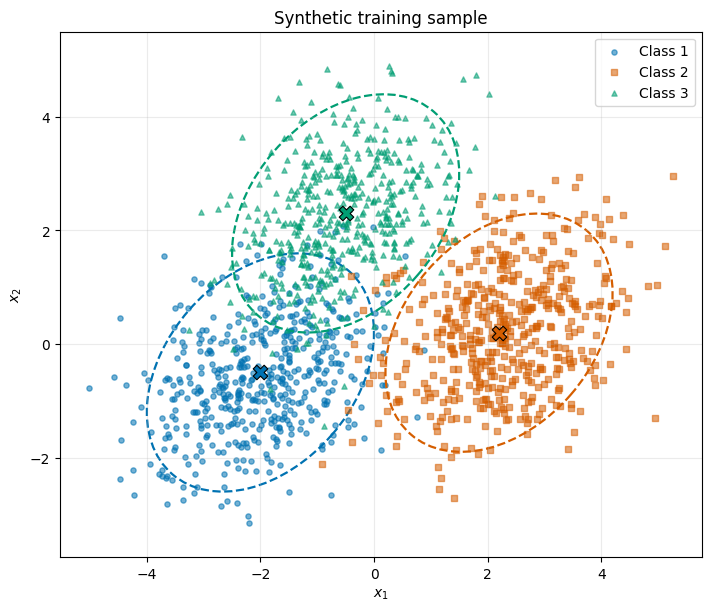

In [2]:
from matplotlib.patches import Ellipse

x_train, y_train = train_ds.tensors
x_np = x_train.numpy()
y_np = y_train.numpy()
colors = ('#0072B2', '#D55E00', '#009E73')
markers = ('o', 's', '^')

def covariance_ellipse(mean, cov, radius=2.0, **kwargs):
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    return Ellipse(mean, width=2 * radius * np.sqrt(eigenvalues[0]),
                   height=2 * radius * np.sqrt(eigenvalues[1]), angle=angle, **kwargs)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
for c in range(C):
    points = x_np[y_np == c]
    ax.scatter(points[:, 0], points[:, 1], s=14, color=colors[c],
               marker=markers[c], alpha=0.55, label=f'Class {c + 1}')
    ax.scatter(*mus[c], marker='X', s=110, color=colors[c],
               edgecolor='black', linewidth=0.8, zorder=3)
    ax.add_patch(covariance_ellipse(mus[c], Sigma, edgecolor=colors[c],
                                    facecolor='none', linestyle='--', linewidth=1.6))
ax.set(xlabel=r'$x_1$', ylabel=r'$x_2$', title='Synthetic training sample')
ax.set_aspect('equal', adjustable='datalim')
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## Train both models and audit hard negatives

A small encoder maps the raw 2D points through Linear(2, 16), Tanh, and Linear(16, 2). Its two-dimensional outputs feed an LDA head with learned class means, a full shared covariance, and priors. The encoder and head are trained jointly; `encoder_hidden_dim` and `latent_dim` control their sizes.

DNLL and logistic training start from identical encoder and head parameters and use the same minibatch order. The complete train and test sets are audited after each epoch. Accuracy and hard5 audits use clean labels on both splits. Run this cell before the decision-boundary and hard5 plots.


In [3]:
from copy import deepcopy
from torch import nn


class NeuralLDA(nn.Module):
    def __init__(self, input_dim, hidden_dim, feature_dim, num_classes):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, feature_dim),
        )
        self.head = LDAHead(num_classes, feature_dim, covariance_type='full')

    def forward(self, x):
        return self.head(self.encoder(x))

@torch.no_grad()
def audit_split(model, loader, split, epoch, loss_name):
    model.eval()
    collected = {name: [] for name in ('g', 'margin', 's_c_star', 'p_neg_max', 'p_mix')}
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        scores = model(x)
        correct += (scores.argmax(1) == y).sum().item()
        total += len(y)
        s_y = scores.gather(1, y[:, None]).squeeze(1)
        wrong = scores.clone()
        wrong.scatter_(1, y[:, None], float('-inf'))
        s_c_star = wrong.max(dim=1).values
        exp_wrong = torch.exp(s_c_star.clamp(-50, 50))
        values = {
            'g': torch.sigmoid(s_c_star) if loss_name == 'logistic' else exp_wrong,
            'margin': s_y - s_c_star,
            's_c_star': s_c_star,
            'p_neg_max': exp_wrong,
            'p_mix': torch.exp(scores.clamp(-50, 50)).sum(dim=1),
        }
        for name, value in values.items():
            collected[name].append(value.cpu())
    collected = {name: torch.cat(parts) for name, parts in collected.items()}
    cutoff = torch.quantile(collected['s_c_star'], 0.95)
    hard_mask = collected['s_c_star'] >= cutoff
    records = []
    for group, mask in (('all', torch.ones(total, dtype=torch.bool)), ('hard5', hard_mask)):
        record = {'epoch': epoch, 'split': split, 'group': group, 'loss': loss_name,
                  'count': int(mask.sum()), 'accuracy': correct / total}
        for name, value in collected.items():
            selected = value[mask].float()
            record[f'{name}_mean'] = selected.mean().item()
            record[f'{name}_median'] = selected.median().item()
            record[f'{name}_p90'] = torch.quantile(selected, 0.9).item()
        records.append(record)
    return records

# Reset the seed so rerunning this cell repeats the same initialization.
torch.manual_seed(seed)
initial_model = NeuralLDA(D, encoder_hidden_dim, latent_dim, C)
initial_state = deepcopy(initial_model.state_dict())
losses = {'dnll': DNLLLoss(lambda_reg=1.0), 'logistic': LogisticLoss()}
history = []
models = {}
for loss_name, loss_fn in losses.items():
    model = NeuralLDA(D, encoder_hidden_dim, latent_dim, C).to(device)
    model.load_state_dict(initial_state)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              generator=torch.Generator().manual_seed(seed + 1))
    for epoch in range(1, epochs + 1):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            loss = loss_fn(model(x), y)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
        for split, loader in probe_loaders.items():
            history.extend(audit_split(model, loader, split, epoch, loss_name))
    models[loss_name] = model
    for split in probe_loaders:
        final = next(r for r in history if r['loss'] == loss_name and r['epoch'] == epochs
                     and r['split'] == split and r['group'] == 'hard5')
        print(f"{loss_name} {split}: accuracy={final['accuracy']:.3f}, hard5 count={final['count']}")


dnll train: accuracy=0.927, hard5 count=75
dnll test: accuracy=0.924, hard5 count=75
logistic train: accuracy=0.921, hard5 count=75
logistic test: accuracy=0.919, hard5 count=75


## Learned decision boundaries

Each panel shows the same training points. The background indicates the predicted class, and the black lines mark where the predicted class changes.
Predictions pass the original input grid through the trained encoder and LDA head, so the boundaries can be nonlinear in the input coordinates.


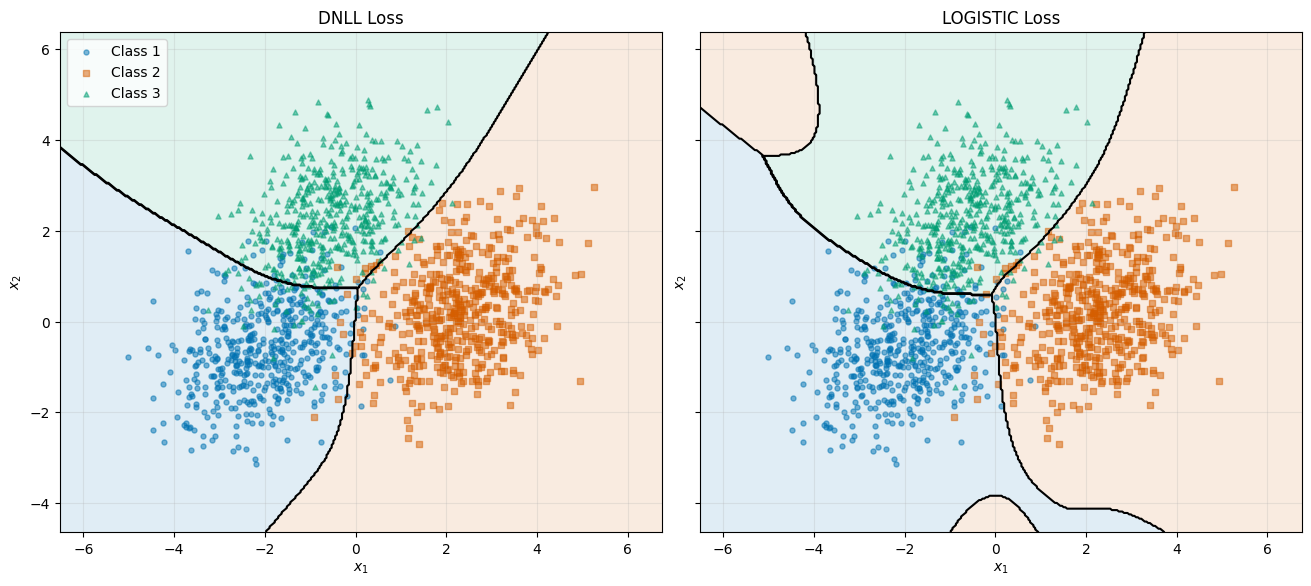

In [4]:
from matplotlib.colors import ListedColormap

pad = 1.5
x_min, y_min = x_np.min(axis=0) - pad
x_max, y_max = x_np.max(axis=0) + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 350),
                     np.linspace(y_min, y_max, 350))
grid = torch.tensor(np.column_stack((xx.ravel(), yy.ravel())),
                    dtype=x_train.dtype, device=device)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.7), constrained_layout=True,
                         sharex=True, sharey=True)
region_colors = ListedColormap(colors)
for ax, (loss_name, model) in zip(axes, models.items()):
    model.eval()
    with torch.no_grad():
        predicted = model(grid).argmax(dim=1).cpu().numpy().reshape(xx.shape)
    ax.contourf(xx, yy, predicted, levels=np.arange(C + 1) - 0.5,
                cmap=region_colors, alpha=0.12)
    ax.contour(xx, yy, predicted, levels=np.arange(C - 1) + 0.5,
               colors='black', linewidths=1.5)
    for c in range(C):
        points = x_np[y_np == c]
        ax.scatter(points[:, 0], points[:, 1], s=13, color=colors[c],
                   marker=markers[c], alpha=0.5, label=f'Class {c + 1}')
    ax.set(title=f'{loss_name.upper()} Loss', xlabel=r'$x_1$', ylabel=r'$x_2$',
           xlim=(x_min, x_max), ylim=(y_min, y_max))
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.25)
axes[0].legend(loc='upper left')
plt.show()


## Learned latent spaces

Each panel shows the training examples after passing through that model's encoder, colored by their clean training labels. The background and black boundaries are predictions from the LDA head directly in latent space. Each model learns its own coordinates, so the panel limits are fitted independently. Set `latent_split = 'test'` to view the test sample instead. This plot uses the two-dimensional latent representation (`latent_dim = 2`).

Square viewing windows preserve equal units on both axes without squeezing the panels. The embeddings can still form thin or curved clusters: the encoder is optimized for the classification loss, with no requirement that its outputs have a Gaussian shape.


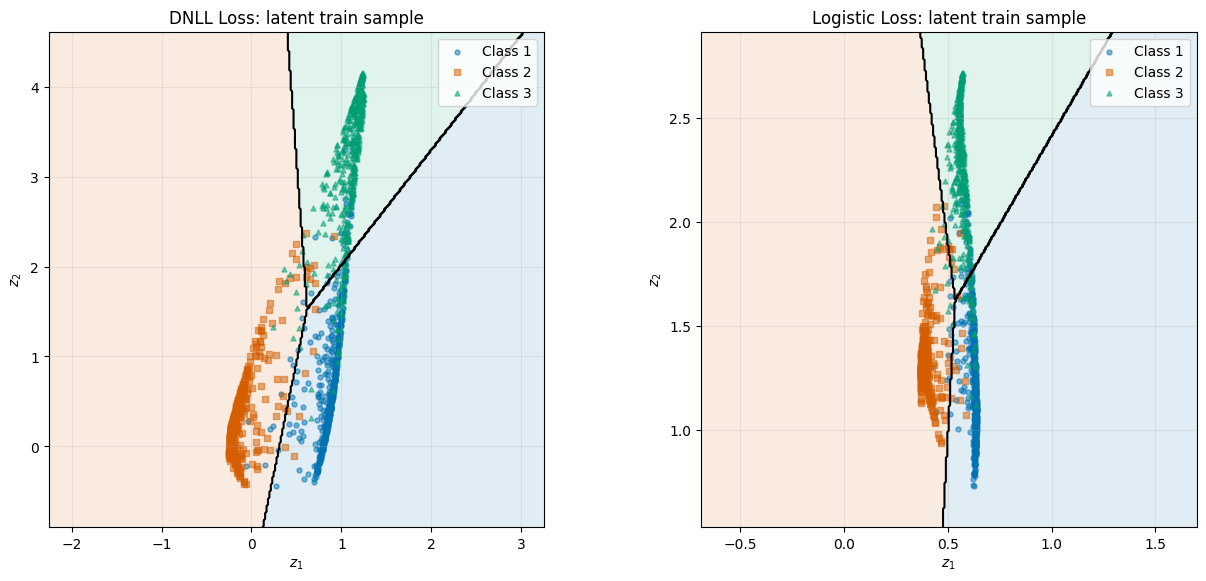

In [5]:
from matplotlib.colors import ListedColormap

latent_split = 'train'  # 'train' or 'test'
latent_datasets = {'train': train_ds, 'test': test_ds}
latent_inputs, latent_labels = latent_datasets[latent_split].tensors
latent_labels_np = latent_labels.numpy()

if any(model.head.D != 2 for model in models.values()):
    raise ValueError('This plot requires latent_dim = 2; set it and rerun training.')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.7), constrained_layout=True)
for ax, (loss_name, model) in zip(axes, models.items()):
    model.eval()
    with torch.no_grad():
        latent_points = model.encoder(latent_inputs.to(device)).cpu().numpy()

    # Square limits keep equally scaled axes from becoming narrow strips.
    # Use the larger span for both axes, with 10% padding on each side.
    latent_min = latent_points.min(axis=0)
    latent_max = latent_points.max(axis=0)
    latent_center = (latent_min + latent_max) / 2
    latent_half_width = 0.6 * max(float((latent_max - latent_min).max()), 0.1)
    latent_min = latent_center - latent_half_width
    latent_max = latent_center + latent_half_width
    zz1, zz2 = np.meshgrid(np.linspace(latent_min[0], latent_max[0], 350),
                           np.linspace(latent_min[1], latent_max[1], 350))
    latent_grid = torch.tensor(np.column_stack((zz1.ravel(), zz2.ravel())),
                               dtype=latent_inputs.dtype, device=device)
    with torch.no_grad():
        # The grid is already encoded: evaluate only the LDA head here.
        latent_predictions = model.head(latent_grid).argmax(dim=1).cpu().numpy()
    latent_predictions = latent_predictions.reshape(zz1.shape)
    ax.contourf(zz1, zz2, latent_predictions, levels=np.arange(C + 1) - 0.5,
                cmap=ListedColormap(colors), alpha=0.12)
    if np.unique(latent_predictions).size > 1:
        ax.contour(zz1, zz2, latent_predictions, levels=np.arange(C - 1) + 0.5,
                   colors='black', linewidths=1.5)
    for c in range(C):
        points = latent_points[latent_labels_np == c]
        ax.scatter(points[:, 0], points[:, 1], s=13, color=colors[c],
                   marker=markers[c], alpha=0.5, label=f'Class {c + 1}')
    loss_label = 'DNLL Loss' if loss_name == 'dnll' else 'Logistic Loss'
    ax.set(title=f'{loss_label}: latent {latent_split} sample',
           xlabel=r'$z_1$', ylabel=r'$z_2$',
           xlim=(latent_min[0], latent_max[0]), ylim=(latent_min[1], latent_max[1]))
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.25)
    ax.legend(loc='best')
plt.show()


## Mean hardest wrong-class score: train and test

This matches the layout of `logistic-loss/plots/s_c_star_mean_hard5_train_test.png`: separate train and test panels, each comparing DNLL Loss and Logistic Loss. Each plotted point is the mean `s_c_star` within that run's hard5 group at that epoch.


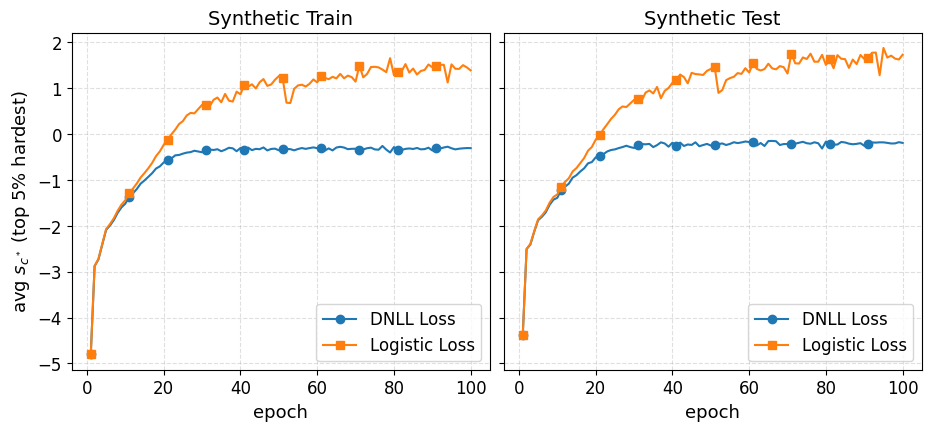

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2), constrained_layout=True, sharey=True)
for ax, split in zip(axes, ('train', 'test')):
    for loss_name, label, marker in (('dnll', 'DNLL Loss', 'o'),
                                     ('logistic', 'Logistic Loss', 's')):
        rows = [r for r in history if r['loss'] == loss_name and r['split'] == split
                and r['group'] == 'hard5']
        ax.plot([r['epoch'] for r in rows], [r['s_c_star_mean'] for r in rows],
                marker=marker, markevery=max(1, epochs // 10), label=label)
    ax.set_title(f'Synthetic {split.title()}', fontsize=14)
    ax.set_xlabel('epoch', fontsize=13)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=12)
axes[0].set_ylabel(r'avg $s_{c^*}$ (top 5% hardest)', fontsize=13)
plt.show()
